# Cluster maps

In [1]:
import fitsio
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, setdiff
import pyccl as ccl
from ulid import ULID

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Opening file

In [3]:
output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
outputfile = output_path + sufix + '.fits'

data = fitsio.FITS(outputfile)
data


  file: Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY
  3      BINARY_TBL      FIT_MINUIT

In [4]:
# data.close()
# original = outputfile
# propre = output_path + 'new.fits'

# with fitsio.FITS(original) as fin:
#     with fitsio.FITS(propre, 'rw', clobber=True) as fout:
#         for i in range(len(fin)):
#             if i == 4: # Ton index de doublon à supprimer
#                 continue
            
#             data = fin[i].read()
#             header = fin[i].read_header()
            
#             # On récupère le nom de l'extension dans le header
#             # .get('EXTNAME') renvoie None si le mot-clé n'existe pas (cas de la Primary HDU)
#             name = header.get('EXTNAME')
            
#             # On écrit en passant l'argument extname
#             fout.write(data, header=header, extname=name)

## Study of numpy method

It is the chatGPT version, using matrix invertion and numpy tools.

In [5]:
dfNumpy = Table(data['FIT_NUMPY'].read()).to_pandas()
dfNumpy

,Map_ID,A,Dx,Dy,Dz
0,01KNRHFD1J62D5NP0SRDEC0FCG,0.000687,-0.000474,0.000267,0.000419
1,01KNRHFD297TAFZ5Q68YCPK2VM,0.000387,0.000055,0.000302,-0.000236
2,01KNRHFD2XDEPBV818WS1J7RMY,0.000453,-0.000048,-0.000256,0.000370
3,01KNRHFD3RZE96226Y8AYCBX44,0.000285,-0.000273,-0.000040,-0.000074
4,01KNRHFD45ET7XHNHGDBBZBR7X,0.000539,0.000383,0.000317,0.000207
...,...,...,...,...,...
9995,01KNRNDH3XQBH45KSDSC0R5F6D,0.000975,-0.000548,-0.000262,0.000763
9996,01KNRNDH429YRKDE22FVY9116E,0.000413,0.000303,0.000272,0.000068
9997,01KNRNDH48V6ETZTZTZ9ZTNAGB,0.000845,0.000391,-0.000097,0.000743
9998,01KNRNDH4EG5WY64YG8PM658JB,0.000668,-0.000083,0.000518,0.000413


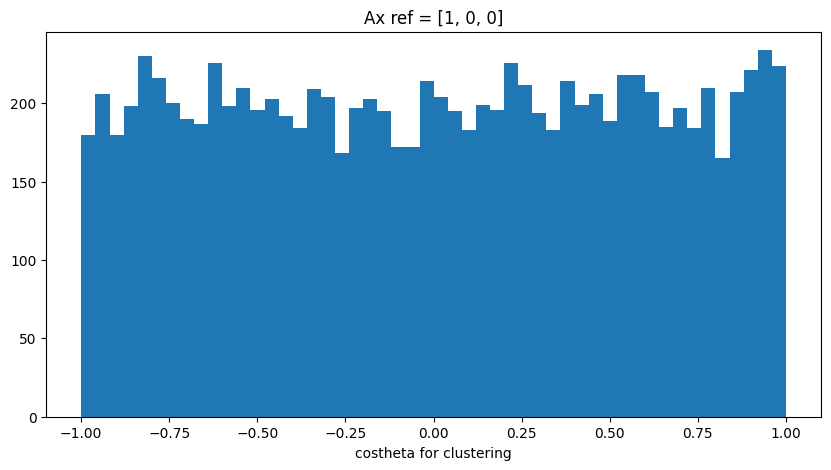

In [6]:
def get_costheta_cartesian(df, axref=[1, 0, 0]):
    data = df.copy()
    axref = np.array(axref)
    axref = axref/np.linalg.norm(axref)
    dip = np.array(data[['Dx', 'Dy', 'Dz']])
    return np.dot(dip, axref)/data['A']

axref = [1, 0, 0]
dfNumpy['costheta'] = dfNumpy.apply(get_costheta_cartesian, axis=1, args=(axref,))
col = 'costheta'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(dfNumpy[col], xlabel=f"{col} for clustering", bins=50, figax=(fig, ax), title=f"Ax ref = {axref}");

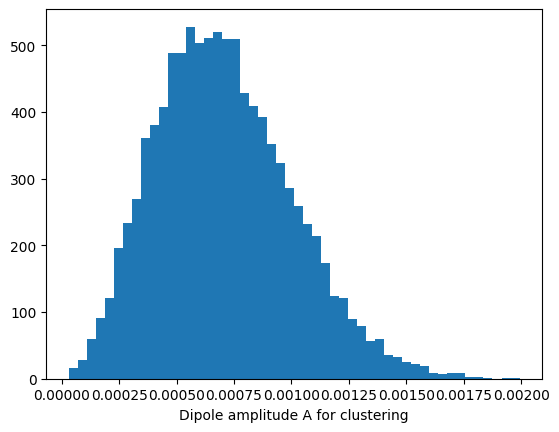

In [7]:
col = 'A'
fig, ax = plt.subplots()
get_hist(dfNumpy[col], xlabel=f"Dipole amplitude {col} for clustering", bins=50, figax=(fig, ax));

In [8]:
dfNumpy.describe()

,A,Dx,Dy,Dz,costheta
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,0.000707,0.000002,-7.693099e-07,-4.658319e-08,0.007257
std,0.000297,0.000446,4.402594e-04,4.428252e-04,0.581251
min,0.000030,-0.001693,-1.547497e-03,-1.713045e-03,-0.999241
25%,0.000489,-0.000304,-2.955812e-04,-3.017372e-04,-0.503932
50%,0.000683,0.000008,-3.325031e-06,-2.818449e-07,0.015391
75%,0.000899,0.000301,3.018153e-04,2.981659e-04,0.514121
max,0.001993,0.001584,1.815689e-03,1.728033e-03,0.999735


In [9]:
def get_lb(df):
    data = df.copy()
    xyz = np.array(data[['Dx', 'Dy', 'Dz']])
    dip = SkyCoord(*xyz, frame='galactic', representation_type='cartesian', unit=u.pc)
    return dip.spherical.lon.value, dip.spherical.lat.value

dfNumpy[['l', 'd']] = dfNumpy.apply(get_lb, axis=1, result_type='expand')
dfNumpy

,Map_ID,A,Dx,Dy,Dz,costheta,l,d
0,01KNRHFD1J62D5NP0SRDEC0FCG,0.000687,-0.000474,0.000267,0.000419,-0.690668,150.593228,37.550390
1,01KNRHFD297TAFZ5Q68YCPK2VM,0.000387,0.000055,0.000302,-0.000236,0.141716,79.703455,-37.547447
2,01KNRHFD2XDEPBV818WS1J7RMY,0.000453,-0.000048,-0.000256,0.000370,-0.105558,259.424785,54.888827
3,01KNRHFD3RZE96226Y8AYCBX44,0.000285,-0.000273,-0.000040,-0.000074,-0.955430,188.403990,-15.027610
4,01KNRHFD45ET7XHNHGDBBZBR7X,0.000539,0.000383,0.000317,0.000207,0.711229,39.618266,22.586268
...,...,...,...,...,...,...,...,...
9995,01KNRNDH3XQBH45KSDSC0R5F6D,0.000975,-0.000548,-0.000262,0.000763,-0.561603,205.566075,51.496777
9996,01KNRNDH429YRKDE22FVY9116E,0.000413,0.000303,0.000272,0.000068,0.734312,41.883875,9.489432
9997,01KNRNDH48V6ETZTZTZ9ZTNAGB,0.000845,0.000391,-0.000097,0.000743,0.462524,346.082889,61.542175
9998,01KNRNDH4EG5WY64YG8PM658JB,0.000668,-0.000083,0.000518,0.000413,-0.124974,99.152883,38.218712


## Study of minuit method

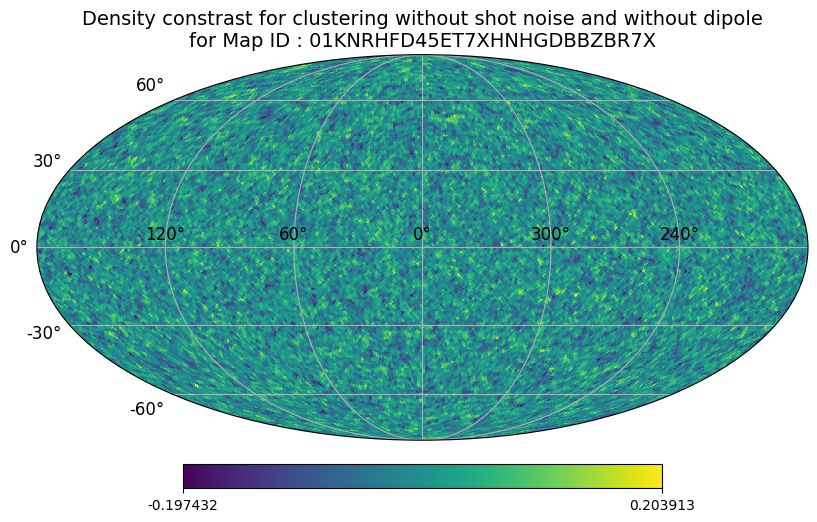

In [10]:
def get_indexID(fits, ID, HDU='MAPS'):
    if type(ID) == np.ndarray or type(ID) == list or type(ID) == tuple:
        idx = [get_index(fits, id, HDU) for id in ID]
    else: idx = fits[HDU].where(f'Map_ID == "{ID}"')
    return idx
    

def hasID_fits(fits, ID, HDU='MAPS'):
    """Check if an ID or a list of IDs is in the HDU of the fits.
    Return True if it is, and False if not."""
    return np.isin(ID, fits[HDU]['Map_ID'][:])


def get_ID_not_in(fits, HDU_ref ='FIT_MINUIT', HDU_target='MAPS'):
    """Return the IDs in HDU_target that are not in HDU_ref."""
    ID_ref = fits[HDU_ref].read(columns='Map_ID')
    ID_target = fits[HDU_target].read(columns='Map_ID')
    not_in = np.isin(ID_target, ID_ref, invert=True)
    return ID_target[not_in]


mapID = get_ID_not_in(data, HDU_ref ='FIT_MINUIT', HDU_target='MAPS')[0] #first map not fitted yet by minuit
idxID = get_indexID(data, mapID)
map = data['MAPS']['Map'][idxID][0]
title=f"Density constrast for clustering without shot noise and without dipole\nfor Map ID : {mapID}"
hp.projview(map, title=title, graticule=True, graticule_labels=True);

In [11]:
def get_dicParam_minuit(m, mapID, add_param={}, to_pandas=True):
    """Return the dictionnary of fit results useful to be saved in an external file."""
    dic_param = {"Map_ID": mapID}
    for k, v in m.values.to_dict().items():
        dic_param[k] = v
        dic_param[k + "_init"] = m.init_params[k].value
        dic_param[k + "_err"] = m.errors[k]
        dic_param[k + "_fixed"] = m.fixed[k]
        dic_param[k + "_limit_0"] = m.limits[k][0] #separated to make easier convertion Table to pd.DataFrame.
        dic_param[k + "_limit_1"] = m.limits[k][1]
    dic_param["valid"] = m.valid
    for k, v in add_param.items(): dic_param[k] = v
    if to_pandas: dic_param = pd.DataFrame([dic_param])
    return dic_param

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1863 (χ²/ndof = 0.0)       │              Nfcn = 304              │
│ EDM = 2.41e-05 (Goal: 0.0002)    │            time = 2.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ A    │  0.06e-3  │  1.73e-3  │  -0.06e-3  │  0.63e-3   │    0    │    1    │       │
│ 2 │ l    │    70     │    310    │    -70     │    290     │    0    │   360   │       │
│ 3 │ b    │    -10    │    110    │    -80     │    100     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.06e-3  │  0.63e-3  │    -70    │    290    │    -80    │    100    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────┐
│   │          M          A          l          b │
├───┼─────────────────────────────────────────────┤
│ M │          0          0          0          0 │
│ A │          0   3.95e-07 16.5428e-3 10.6032e-3 │
│ l │          0 16.5428e-3   2.28e+05    -0.02e6 │
│ b │          0 10.6032e-3    -0.02e6   3.81e+05 │
└───┴─────────────────────────────────────────────┘

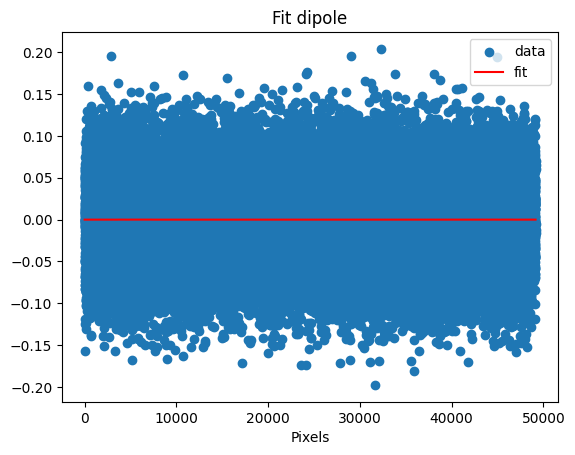

In [12]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='icrs')
init =  (0, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), fixed="M")
dic_param = get_dicParam_minuit(m, mapID, add_param={'Coord': 'spherical'})
dfMinuit = dic_param.copy()
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1863 (χ²/ndof = 0.0)       │              Nfcn = 333              │
│ EDM = 3.06e-06 (Goal: 0.0002)    │            time = 2.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ A    │  0.06e-3  │  1.69e-3  │  -0.06e-3  │  0.63e-3   │    0    │    1    │       │
│ 2 │ l    │    60     │    320    │    -60     │    300     │    0    │   360   │       │
│ 3 │ b    │    -10    │    110    │    -80     │    100     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.06e-3  │  0.63e-3  │    -60    │    300    │    -80    │    100    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────┐
│   │          M          A          l          b │
├───┼─────────────────────────────────────────────┤
│ M │          0          0          0          0 │
│ A │          0   3.92e-07 43.6478e-3  3.4084e-3 │
│ l │          0 43.6478e-3   2.32e+05    -0.01e6 │
│ b │          0  3.4084e-3    -0.01e6   3.75e+05 │
└───┴─────────────────────────────────────────────┘

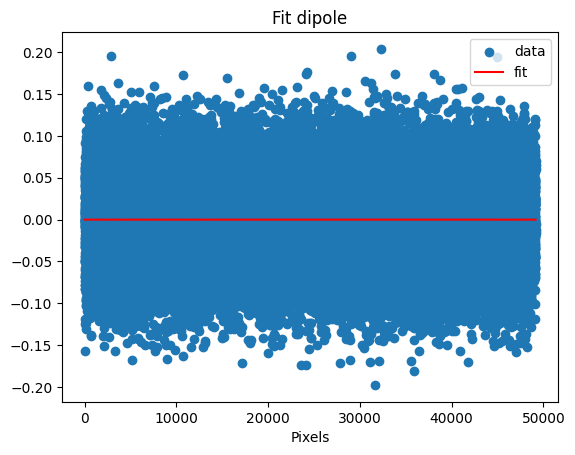

In [13]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='icrs')
init =  (0, 3, 120, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), fixed="M")
dic_param = get_dicParam_minuit(m, mapID, add_param={'Coord': 'spherical'})
dfMinuit = pd.concat([dfMinuit, dic_param], ignore_index=True)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1863 (χ²/ndof = 0.0)       │              Nfcn = 139              │
│ EDM = 4.85e-05 (Goal: 0.0002)    │            time = 0.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ Dx   │     0     │  0.5e-3   │  -0.5e-3   │   0.5e-3   │   -1    │    1    │       │
│ 2 │ Dy   │  0.1e-3   │  0.6e-3   │  -0.6e-3   │   0.6e-3   │   -1    │    1    │       │
│ 3 │ Dz   │    -0     │  0.6e-3   │  -0.6e-3   │   0.6e-3   │   -1    │    1    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          Dx           │          Dy           │          Dz           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.5e-3  │  0.5e-3   │  -0.6e-3  │  0.6e-3   │  -0.6e-3  │  0.6e-3   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────┬─────────────────────────────────────┐
│    │        M       Dx       Dy       Dz │
├────┼─────────────────────────────────────┤
│  M │        0        0        0        0 │
│ Dx │        0 2.34e-07  0.04e-6  0.02e-6 │
│ Dy │        0  0.04e-6 3.89e-07       -0 │
│ Dz │        0  0.02e-6       -0 3.82e-07 │
└────┴─────────────────────────────────────┘

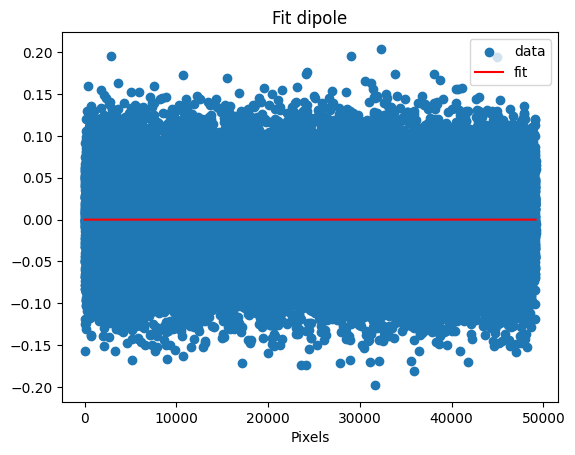

In [14]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='cartesian')
init =  (0, 0, 0, 0)
names = ("M", "Dx", "Dy", "Dz")
m = fit_dipole_err(model, map, init, names, bounds=([0, -1, -1, -1], [np.inf, 1, 1, 1]), fixed="M")
dic_param = get_dicParam_minuit(m, mapID, add_param={'Coord': 'cartesian'})
dfMinuit = pd.concat([dfMinuit, dic_param], ignore_index=True)
m

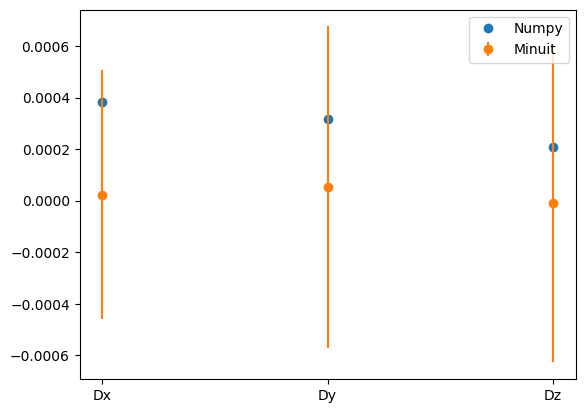

In [15]:
plt.plot(dfNumpy.set_index('Map_ID').loc[mapID][['Dx', 'Dy', 'Dz']], marker='o', linestyle='', label='Numpy')
plt.errorbar(['Dx', 'Dy', 'Dz'], dic_param.loc[0][['Dx', 'Dy', 'Dz']], yerr=dic_param.loc[0][['Dx_err', 'Dy_err', 'Dz_err']], marker='o', linestyle='', label='Minuit')
plt.legend();

In [16]:
dfMinuit

,Map_ID,M,M_init,M_err,M_fixed,M_limit_0,M_limit_1,A,A_init,A_err,...,Dy_err,Dy_fixed,Dy_limit_0,Dy_limit_1,Dz,Dz_init,Dz_err,Dz_fixed,Dz_limit_0,Dz_limit_1
0,01KNRHFD45ET7XHNHGDBBZBR7X,0.0,0.0,0.1,True,0.0,inf,0.000057,1.0,0.001733,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01KNRHFD45ET7XHNHGDBBZBR7X,0.0,0.0,0.1,True,0.0,inf,0.000058,1.0,0.001688,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01KNRHFD45ET7XHNHGDBBZBR7X,0.0,0.0,0.1,True,0.0,inf,NaN,NaN,NaN,...,0.000623,False,-1.0,1.0,-0.00001,0.0,0.000618,False,-1.0,1.0


In [17]:
def prep_df_to_fits(df):
    data = df.copy()
    data['Coord'] = data['Coord'].astype('U9')
    for col in data.columns:
        if col.endswith('_fixed'):
            data[col].fillna(False, inplace=True)
    return data


def get_not_in_fits_ID(df, fits, HDU='MAPS'):
    """From a dataframe, return only the rows corresponding to ID that are not already in the HDU of a fits.
    Espectially usefull to avoid saving twice the same map."""
    in_fits = hasID_fits(fits, np.array(df['Map_ID']), HDU)
    return df[~in_fits]


def get_row_not_in(df1, df2=Table(data['FIT_MINUIT'].read()), as_table=True):
    """From a dataframe df1, return only the rows that are not in another dataframe df2.
    Espectially usefull to avoid saving twice the same fit result from iminuit."""
    if type(df1) == Table: df1 = df1.to_pandas()
    if type(df2) == Table: df2 = df2.to_pandas()
    df_merge = df1.merge(df2, how='left', indicator=True)
    rows = df_merge[df_merge['_merge'] == 'left_only'].drop('_merge', axis=1)
    if as_table: rows = Table.from_pandas(rows)
    return rows

In [25]:
def save_fit_minuit(dicMinuit, outputfile, HDU_target='FIT_MINUIT'):
    with fitsio.FITS(outputfile, 'rw') as fits: #Ouvrir le fichier en mode écriture ('rw' crée ou écrase)
        if HDU_target in fits: 
            fits[HDU_target].append(dicMinuit)
        else:
            print(f"Coulndn't find HDU {HDU_target} in the data ; creating one.")
            fits.write(dicMinuit, extname=HDU_target)
    print("Saving complete.")


def get_save_fit_dfMinuit(dfMinuit, outputfile, HDU_target='FIT_MINUIT'):
    df = dfMinuit.copy()
    df = prep_df_to_fits(df)
    data = fitsio.FITS(outputfile) #to avoid duplicates.
    if HDU_target in data: df = get_row_not_in(df, Table(data[HDU_target].read()))
    data.close()
    dic = df.as_array()
    if len(dic) == 0: print(f'All the rows already exists in {HDU_target}, or empty table given. No row was saved.')
    else: save_fit_minuit(dic, outputfile, HDU_target)
    return df

data.close()
dfMinuit_filtered = get_save_fit_dfMinuit(dfMinuit, outputfile)

All the rows already exists in FIT_MINUIT, or empty table given. No row was saved.


/tmp/ipykernel_51469/3199020060.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(False, inplace=True)
/tmp/ipykernel_51469/3199020060.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col].fillna(False, inplace=True)


In [20]:
data = fitsio.FITS(outputfile)
Table(data['FIT_MINUIT'].read())

Map_ID,M,M_init,M_err,M_fixed,M_limit_0,M_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,l,l_init,l_err,l_fixed,l_limit_0,l_limit_1,b,b_init,b_err,b_fixed,b_limit_0,b_limit_1,valid,Coord,Dx,Dx_init,Dx_err,Dx_fixed,Dx_limit_0,Dx_limit_1,Dy,Dy_init,Dy_err,Dy_fixed,Dy_limit_0,Dy_limit_1,Dz,Dz_init,Dz_err,Dz_fixed,Dz_limit_0,Dz_limit_1
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str9,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64
01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,0.0,inf,6.571938794718704e-05,1.0,0.0012829626308812733,False,0.0,1.0,172.2025129415633,20.0,269.36635249397676,False,0.0,360.0,89.9883297828077,40.0,154.3772671225816,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,0.0,inf,9.054407968689602e-05,1.0,0.0009356310207443497,False,0.0,1.0,179.0796755032638,120.0,234.17225678531386,False,0.0,360.0,46.16689258903281,40.0,109.02212464033062,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,0.0,inf,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,True,cartesian,-6.020468248102895e-05,0.0,0.0005919651020845076,False,-1.0,1.0,1.7029782001764778e-06,0.0,0.0004822375055840672,False,-1.0,1.0,6.421841956433705e-05,0.0,0.0005854549737822537,False,-1.0,1.0
01KNRHFD297TAFZ5Q68YCPK2VM,0.0,0.0,0.1,True,0.0,inf,8.197160031699633e-06,1.0,0.006688229506890044,False,0.0,1.0,181.3298257099353,120.0,262.9126559119843,False,0.0,360.0,-77.40396786292919,40.0,165.70552583408494,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD297TAFZ5Q68YCPK2VM,0.0,0.0,0.1,True,0.0,inf,1.682983186405954e-05,1.0,0.004347118765357861,False,0.0,1.0,223.8903866877042,20.0,268.89251888083606,False,0.0,360.0,-9.635821735513527,40.0,110.695229464154,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD297TAFZ5Q68YCPK2VM,0.0,0.0,0.1,True,0.0,inf,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,True,cartesian,-1.2286573142766724e-05,0.0,0.000510890342123952,False,-1.0,1.0,-1.0840207930533873e-05,0.0,0.000441962896618399,False,-1.0,1.0,-3.8100722612126716e-07,0.0,0.000552294410210185,False,-1.0,1.0
01KNRHFD2XDEPBV818WS1J7RMY,0.0,0.0,0.1,True,0.0,inf,2.8412584295137378e-05,1.0,0.002975147777360052,False,0.0,1.0,0.028041438317023493,20.0,357.5689949380369,False,0.0,360.0,58.14819308197867,40.0,98.41826541592259,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD2XDEPBV818WS1J7RMY,0.0,0.0,0.1,True,0.0,inf,3.200068844633894e-05,1.0,0.0026314365958661793,False,0.0,1.0,0.41143552965567587,120.0,357.8808795263201,False,0.0,360.0,62.458915989845615,40.0,108.40757439349522,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD2XDEPBV818WS1J7RMY,0.0,0.0,0.1,True,0.0,inf,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,True,cartesian,1.4824274233782905e-05,0.0,0.00048028105551291457,False,-1.0,1.0,-1.3605490205693667e-05,0.0,0.0005381447792566276,False,-1.0,1.0,2.2887805042880638e-05,0.0,0.0005291979110260616,False,-1.0,1.0
